<a href="https://colab.research.google.com/github/Sina-Haz/fastai-pt-2/blob/main/Diffusion_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
import torch

if torch.cuda.is_available():
    # Shows the nVidia GPUs, if this system has any
    !nvidia-smi

Tue Jun 10 19:55:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             30W /   70W |    8638MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
save_dir = '/content/drive/MyDrive/stable-diffusion' # where I saved the model so I can load faster

In [97]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(save_dir, torch_dtype=torch.float16)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [98]:
if torch.cuda.is_available():
    device=torch.device("cuda")
elif torch.backends.mps.is_available():
    device=torch.device("mps")

pipe.to(device) # move to the gpu

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "/content/drive/MyDrive/stable-diffusion",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/50 [00:00<?, ?it/s]

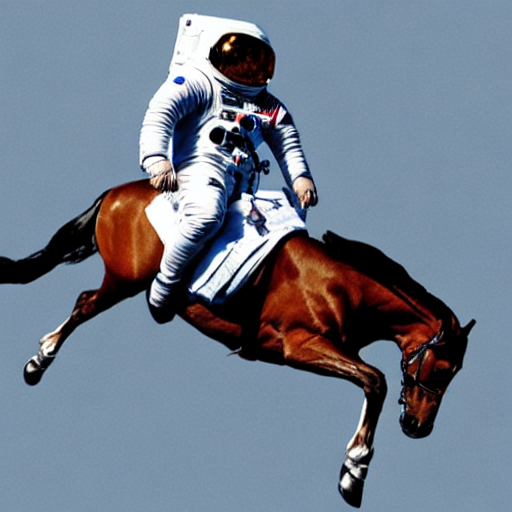

In [99]:
torch.manual_seed(1024)
prompt = "a photograph of an astronaut riding a horse"
image = pipe(prompt).images[0]  # image here is in [PIL format](https://pillow.readthedocs.io/en/stable/)

# Now to display an image you can either save it such as:
image.save(f"astronaut_rides_horse.png")

# or if you're in a google colab you can directly display it with
image

  0%|          | 0/50 [00:00<?, ?it/s]

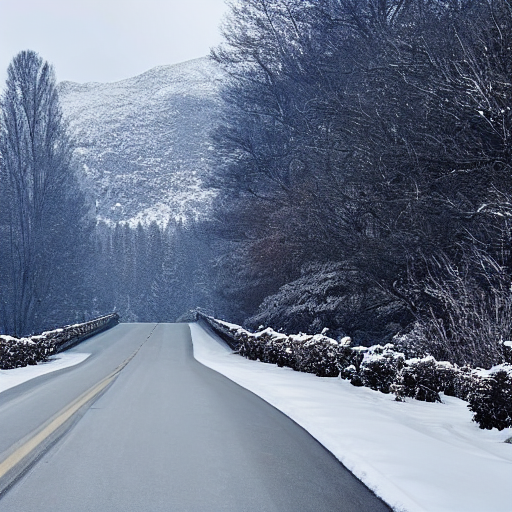

In [100]:
# Can play around with num_inference steps, height and width, as well as guidance_scale which is explained by Classifier free-guidance
gen = torch.Generator(device).manual_seed(1024) # for randomness

prompt = ['Mountain background with an asphalt road leading to it, but its only seen through a heavy snowstorm']

image = pipe(prompt, num_inference_steps=50, guidance_scale=10, generator=gen).images[0]

image

### Writing Custom Pipeline

Instead of loading them individually which may take a while let's just use the components in pipe

In [101]:
 # The VAE -> encodes images to a much smaller latent space (4 x 64 x 64 as opposed to 3 x 512 x 512), then once we are done we can decode
 # the latents back to images. Allows diffusion process to take up less memory and be much faster
 vae = pipe.vae

 type(vae) # for more info peep the docs here: https://huggingface.co/docs/diffusers/v0.33.0/api/models/autoencoderkl

diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL

In [102]:
# unet model takes in a noisy image/latent and "timestep" (where we are in diffusion process), from there it predicts the noise
# on the sample which we subtract off to denoise it. The unet conditional model also takes in a conditional state = embedded text
# This allows it to output conditional score as well as unconditional score when the text = ""
unet = pipe.unet

type(unet) # see docs here: https://huggingface.co/docs/diffusers/v0.33.0/api/models/unet2d-cond

diffusers.models.unets.unet_2d_condition.UNet2DConditionModel

In [103]:
# To be able to handle text prompts we also need a tokenizer to convert text into tokens
# Once we have our tokens we use a CLIP text encoder to turn the tokens into embedding vectors
# which our unet conditional model then can use as input to give a conditional score
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder

type(tokenizer)

transformers.models.clip.tokenization_clip.CLIPTokenizer

In [104]:
type(text_encoder) # see docs here: https://huggingface.co/docs/diffusers/v0.33.0/en/api/text_encoder

transformers.models.clip.modeling_clip.CLIPTextModel

In [105]:
# Instead of using the predefined scheduler we will use the K-LMS scheduler instead
from diffusers import LMSDiscreteScheduler

scheduler = LMSDiscreteScheduler.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="scheduler")

type(scheduler) # see docs here: https://huggingface.co/docs/diffusers/v0.33.0/en/api/scheduler

diffusers.schedulers.scheduling_lms_discrete.LMSDiscreteScheduler

In [106]:
# Let's write down the params we want for generation
txt = 'Mountain background with an asphalt road leading to it, but its only seen through a heavy snowstorm' # same prompt
height,width=512,512
num_inference_steps=100
guidance_scale=7.5
batch_sz = 1
gen = torch.manual_seed(32)

In [107]:
# Let's start by tokenizing our text:
# we ensure there's proper padding, and that the tokenizer returns a tensor rather than a simple list
prompt = [txt]
tokens = tokenizer(prompt, padding="max_length", return_tensors='pt') # index 0 b/c we only have the one prompt

# So as you can see it tokenized the prompt into a tensor of 77 values, where it pads to always have the same end shape of max_length
tokens.input_ids, tokens.attention_mask # this second tensor is boolean for whats actual text and whats padding

(tensor([[49406,  3965,  5994,   593,   550, 30574,  1759,  3833,   531,   585,
            267,   767,   902,  1033,  2041,  1417,   320,  4200, 38777, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
          49407, 49407, 49407, 49407, 49407, 49407, 49407]]),
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0]]))

In [108]:
# Convert our tokens into embeddings
with torch.no_grad():
    text_emb = text_encoder(tokens.input_ids.to(device))[0] # index 0 to get the actual embeddings and can ignore rest of the wrapper
text_emb.shape # Shows we have bs=1 of 77 tokens which are embedding in a 768 dimensional space

torch.Size([1, 77, 768])

In [109]:
# For classifier free-guidance we also need to generate the unconditional score
# therefore we need to create embeddings for empty string

# Let's try to do this in parallel
prompt = [txt, '']

tokens = tokenizer(prompt, padding="max_length", return_tensors='pt')

with torch.no_grad():
    text_emb = text_encoder(tokens.input_ids.to(device))[0]

text_emb.shape

torch.Size([2, 77, 768])

In [110]:
# Next we need to generate our initial noisy latents
# recall that this should be gaussian white noise
# it should be generated by our seeded RNG and should have the same shape which the unet expects
print(unet.config.sample_size, unet.config.in_channels) # so we see that unet expects 4 x 64 x 64

latents = torch.randn(
    (batch_sz, unet.config.in_channels, unet.config.sample_size, unet.config.sample_size),
    generator=gen,
)
latents.shape

64 4


torch.Size([1, 4, 64, 64])

In [111]:
# Before we start passing the latents into our unet, we need to init our scheduler
# with our desired number of inference steps. This will compute the amount of variance used at each timestep

scheduler.set_timesteps(num_inference_steps)

In [112]:
scheduler.timesteps, scheduler.sigmas

(tensor([999.0000, 988.9091, 978.8182, 968.7273, 958.6364, 948.5455, 938.4545,
         928.3636, 918.2727, 908.1818, 898.0909, 888.0000, 877.9091, 867.8182,
         857.7273, 847.6364, 837.5455, 827.4545, 817.3636, 807.2727, 797.1818,
         787.0909, 777.0000, 766.9091, 756.8182, 746.7273, 736.6364, 726.5455,
         716.4545, 706.3636, 696.2727, 686.1818, 676.0909, 666.0000, 655.9091,
         645.8182, 635.7273, 625.6364, 615.5455, 605.4545, 595.3636, 585.2727,
         575.1818, 565.0909, 555.0000, 544.9091, 534.8182, 524.7273, 514.6364,
         504.5454, 494.4546, 484.3636, 474.2727, 464.1818, 454.0909, 444.0000,
         433.9091, 423.8182, 413.7273, 403.6364, 393.5454, 383.4546, 373.3636,
         363.2727, 353.1818, 343.0909, 333.0000, 322.9091, 312.8182, 302.7273,
         292.6364, 282.5454, 272.4546, 262.3636, 252.2727, 242.1818, 232.0909,
         222.0000, 211.9091, 201.8182, 191.7273, 181.6364, 171.5455, 161.4545,
         151.3636, 141.2727, 131.1818, 121.0909, 111

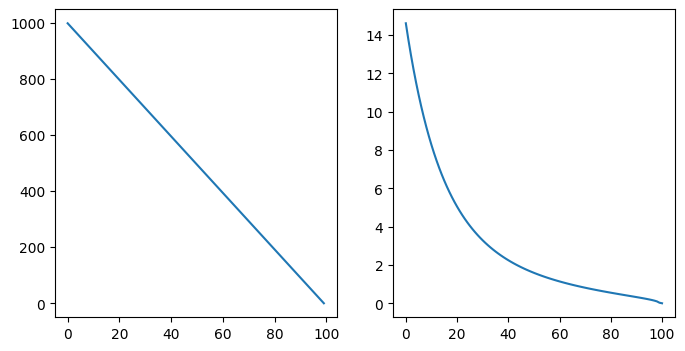

In [113]:
# let's see visually how our scheduler is interpolating time and variance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].plot(scheduler.timesteps)

ax[1].plot(scheduler.sigmas); # ok so interpolates time linearly but noise seems to decrease exponentially

In [114]:
# Multiply our latents ~ N(0, I) by the initial variance to ensure that we are at the correct starting variance
latents = latents * scheduler.sigmas[0]

In [115]:
# Furthermore, recall that we are passing through 2 text embeddings (uncond + prompt) -> so we need to make latents have bs=2
latent_inp = torch.cat([latents]*2)
latent_inp.shape

torch.Size([2, 4, 64, 64])

In [116]:
latent_inp.dtype, text_emb.dtype

(torch.float32, torch.float16)

In [117]:
with torch.autocast('cuda'): # need to use this b/c latents are different precision than text_embeddings
  o = unet(latent_inp.to(device), scheduler.timesteps[0], encoder_hidden_states=text_emb)


In [118]:
type(o), type(o.sample) # get the sample attr of the output to get the tensor

(diffusers.models.unets.unet_2d_condition.UNet2DConditionOutput, torch.Tensor)

In [119]:
o.sample.shape # ok perfect so we got noise predictions one for condition, and one for unconditional

torch.Size([2, 4, 64, 64])

In [120]:
scheduler.config.prediction_type

'epsilon'

In [121]:
# Writing the denoising loop:
from tqdm.auto import tqdm
from torch import autocast

g=guidance_scale
latents = latents.to(device)

with autocast('cuda'):
  for i,t in tqdm(enumerate(scheduler.timesteps), total=len(scheduler.timesteps)):
    latent_input = torch.cat([latents] * 2) # for batch_dim=2=text_emb batch dim

    # We scale the latents with this eqn: l = l / ((sigma**2+1)**0.5)
    latent_input = scheduler.scale_model_input(latent_input, t)

    with torch.no_grad():
      # predict the noise residual
      noise_pred = unet(latent_input, t, encoder_hidden_states=text_emb).sample

    # Get conditional score (c) and unconditional score (u) by splitting along batch dimension
    c, u = noise_pred.chunk(2)
    pred = (1-g)*u + g*c # the original, vanilla classifier free guidance equation

    # Predicts a new sample based on the scheduler.config.prediction_type,
    # For pred_type == 'eps':
    # Step 1: computes next_latent = latents - sigma*noise
    # Step 2: Converts to a derivative, deriv = (latent - next_latent) / sigma
    # Step 3: Does a reverse step of the ODE based on what order of numerical approx we are doing
      # this could be Euler scheme, RK, etc. -> does this b/c it stores the derivatives it computes
      # at previous steps, and thus can use multiple derivatives to compute higher order approximations
    latents = scheduler.step(pred, t, latents).prev_sample # prev_sample b/c it's going reverse in the ODE


  0%|          | 0/100 [00:00<?, ?it/s]

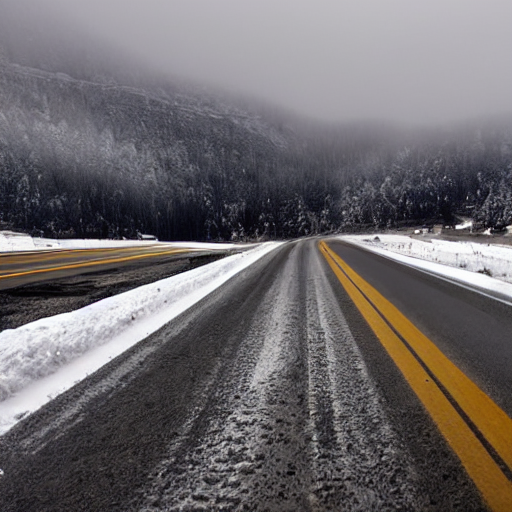

In [122]:
# Now that we have our denoised latents we need to scale them and decode them through the vae to get our image
from PIL import Image

latents = 1 / 0.18215 * latents
with torch.autocast('cuda'):
  with torch.no_grad():
      image = vae.decode(latents).sample

# Display
image = (image / 2 + 0.5).clamp(0, 1)
image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
images = (image * 255).round().astype("uint8")
pil_images = [Image.fromarray(image) for image in images]
pil_images[0] # nice output

### Next: Experimenting with the Pipeline

Let's put everything into quick functions that we can mess around with and change

In [ ]:
scheduler.set_timesteps?

In [122]:
def enc_text(prompts, maxlen=None):
  # Pad up to maxlen (if None defaults to model max len), truncate if prompt is too long
  inp = tokenizer(prompts, padding="max_length", max_length=maxlen, truncation=True, return_tensors="pt")
  return text_encoder(inp.input_ids.to("cuda"))[0].half()

def to_img(dec_latent):
  img = (dec_latent/2 + 0.5).clamp(0, 1).detach().cpu().permute(0, 2, 3, 1).numpy()
  return Image.fromarray((img * 255).round().astype("uint8"))

def gen_image(prompts, g=7.5, seed=100, steps=70):
  bs=len(prompts)# can infer how many images we want to generate concurrently
  txt = enc_text(prompts)
  uncond = text_enc([""] * bs)
  emb = torch.cat([uncond, txt_emb])
  if seed: torch.manual_seed(seed)

  latents = torch.randn((bs, unet.config.in_channels, unet.config.sample_size, unet.config.sample_size))
  scheduler.set_timesteps(steps)
  latents = latents.to("cuda").half() * scheduler.init_noise_sigma

  for i,ts in tqdm(enumerate(scheduler.timesteps)):
    inp = scheduler.scale_model_input(torch.cat([latents] * 2), ts)
    with torch.no_grad():
      u, t = unet(inp, ts, encoder_hidden_states=emb).sample.chunk(2)
    pred = u + g*(t-u)
    latents = scheduler.step(pred, ts, latents).prev_sample

  with torch.no_grad():
    dec = vae.decode(1 / 0.18215 * latents).sample
  return to_img(dec)




